# Pore Shape Recognition Using Contour Method

In [1]:
import os
import shutil 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cv2
from collections import Counter
import random

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 1) Import Curated Images  Dataset

In [2]:
files = "../Images_data/2D_Grids_vdw_curated.npz"

# Load data
data = np.load(files, allow_pickle=True)
images = data["images"] 
names = data["names"].tolist()

print(f"Images shape: {images.shape}")

Images shape: (3855, 500, 500)


# 2) Shape Detection

In [3]:

class ShapeDetector:
    def __init__(self, images, names=None, edge_margin=10, min_area=500):
        self.images = images
        self.names = names if names else [f"img_{i}" for i in range(len(images))]
        self.edge_margin = edge_margin
        self.min_area = min_area

        # Store detected shapes
        self.detected_names_dict = {}  
        self.detected_images_dict = {}

    # ----------------------------- Geometry Helpers -----------------------------
    def angle_between_points(self, p1, p2, p3):
        a, b = np.array(p1) - np.array(p2), np.array(p3) - np.array(p2)
        cos_angle = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)
        return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

    def edge_lengths(self, pts):
        return [np.linalg.norm(pts[i] - pts[(i+1)%len(pts)]) for i in range(len(pts))]

    def edges_equal(self, lengths, tol=0.1):
        mean_len = np.mean(lengths)
        return all(abs(l - mean_len)/mean_len <= tol for l in lengths)


    # ----------------------------- Shape Detection -----------------------------#
    def detect_shapes(self, desired_shape="triangle", epsilon=0.03,
                      angle_tolerance=5, edge_tol=0.1, perimeter_ratio=1.28):
    
        self.detected_names_dict[desired_shape] = []
        self.detected_images_dict[desired_shape] = []
    
        for idx, img_array in enumerate(self.images):
            # Ensure uint8 binary format
            img_uint8 = (img_array * 255).astype(np.uint8)
            h, w = img_uint8.shape

            # Contours directly from binary
            contours, _ = cv2.findContours(img_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            output = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)/255
            shape_found = False
    
            for cnt in contours:
                if cv2.contourArea(cnt) < self.min_area:
                    continue
    
                perimeter = cv2.arcLength(cnt, True)
                approx = cv2.approxPolyDP(cnt, epsilon * perimeter, True)
                pts = approx.reshape(-1, 2)
                num_vertices = len(pts)
    
                # Skip shapes touching image border
                if any(x <= self.edge_margin or x >= w - self.edge_margin or
                       y <= self.edge_margin or y >= h - self.edge_margin for x, y in pts):
                    continue
    
                angles = [self.angle_between_points(pts[i-1], pts[i], pts[(i+1) % num_vertices])
                          for i in range(num_vertices)]
                lengths = self.edge_lengths(pts)
                shape_name = None
    
                # ---------------- Triangle vs Trilobal ----------------
                if num_vertices == 3 and self.edges_equal(lengths, tol=edge_tol):
    
                    P_triangle = sum([
                        np.linalg.norm(pts[i] - pts[(i+1) % 3])
                        for i in range(3)
                    ])
                
                    # 3) Actual contour perimeter
                    P_contour = cv2.arcLength(cnt, True)
                
                    # 4) Perimeter inflation ratio
                    pr = P_contour / (P_triangle + 1e-8)
                
                    # 5) NEW: classify based on perimeter tolerance
                    # trilobal has inflated perimeter due to lobes
                    if pr > perimeter_ratio:
                        shape_name = "trilobal"
                    else:
                        shape_name = "triangle"
                # ---------------- Square ----------------
                if num_vertices == 4:
                    if all(90 - angle_tolerance <= a <= 90 + angle_tolerance for a in angles) and \
                       self.edges_equal(lengths, tol=edge_tol):
                        shape_name = "square"
    
                # ---------------- Hexagon ----------------
                if num_vertices == 6 and \
                   all(120 - angle_tolerance <= a <= 120 + angle_tolerance for a in angles) and \
                   self.edges_equal(lengths, tol=edge_tol):
                    shape_name = "hexagon"
    
                # ---------------- Circle ----------------
                if num_vertices > 8:
                    area = cv2.contourArea(cnt)
                    circ = 4 * np.pi * area / (perimeter**2 + 1e-8)
                    if circ > 0.8:
                        shape_name = "circle"
    
                # ---------------- Star ----------------
                if num_vertices == 12:
                    sharp_angles = sum(a < 80 for a in angles)
                    wide_angles  = sum(a > 100 for a in angles)
    
                    if 5 <= sharp_angles <= 6 and 5 <= wide_angles <= 6:
                        shape_name = "star"
    
                if shape_name == desired_shape:
                    shape_found = True
    
            if shape_found:
                self.detected_names_dict[desired_shape].append(self.names[idx])
                self.detected_images_dict[desired_shape].append(output)
    
        return self.detected_names_dict[desired_shape], self.detected_images_dict[desired_shape]




In [4]:
# -----------------------------
# Traingle shapes
# -----------------------------
my_shape = "triangle"

detector = ShapeDetector(images=images, names=names, edge_margin=10, min_area=1000)
detected_names, detected_images = detector.detect_shapes(desired_shape=my_shape, epsilon=0.05, edge_tol=0.1, perimeter_ratio=1.28)
print("Detected images with potential "+my_shape+" shapes:", len(detected_names))


Detected images with potential triangle shapes: 17


max 1.0


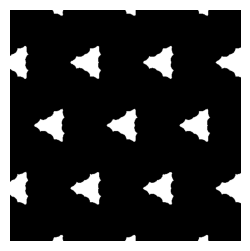

In [5]:
#visulizae one example
index = detected_names.index(detected_names[2])
img_array = detected_images[index]
print('max', np.max(img_array))

plt.figure(figsize=(3,3))
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()

In [6]:
# -----------------------------
# Trilobal shapes
# -----------------------------
my_shape = "trilobal"

detector = ShapeDetector(images=images, names=names, edge_margin=10, min_area=1000)
detected_names, detected_images = detector.detect_shapes(desired_shape=my_shape, epsilon=0.05, edge_tol=0.1, perimeter_ratio=1.28)
print("Detected images with potential "+my_shape+" shapes:", len(detected_names))

Detected images with potential trilobal shapes: 15


max 1.0


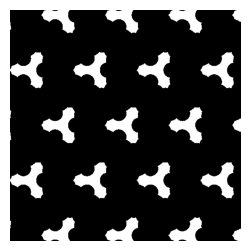

In [7]:
#visulizae one example
index = detected_names.index(detected_names[0])
img_array = detected_images[index]
print('max', np.max(img_array))

plt.figure(figsize=(3,3))
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()

In [8]:
# -----------------------------
# Squre shapes
# -----------------------------
my_shape = "square"

detector = ShapeDetector(images=images, names=names, edge_margin=10, min_area=1000)
detected_names, detected_images = detector.detect_shapes(desired_shape=my_shape, epsilon=0.02, angle_tolerance=5, edge_tol=0.1)
print("Detected images with potential "+my_shape+" shapes:", len(detected_names))

Detected images with potential square shapes: 109


max 1.0


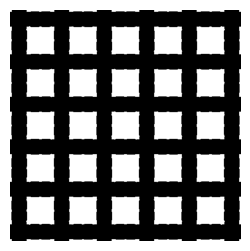

In [9]:
#visulizae one example
index = detected_names.index(detected_names[0])
img_array = detected_images[index]
print('max', np.max(img_array))

plt.figure(figsize=(3,3))
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()

In [10]:
# -----------------------------
# Circle shapes
# -----------------------------
my_shape = "circle"

detector = ShapeDetector(images=images, names=names, edge_margin=10, min_area=1000)
detected_names, detected_images = detector.detect_shapes(desired_shape=my_shape, epsilon=0.01,)# angle_tolerance=5, edge_tol=1)
print("Detected images with potential "+my_shape+" shapes:", len(detected_names))

Detected images with potential circle shapes: 42


max 1.0


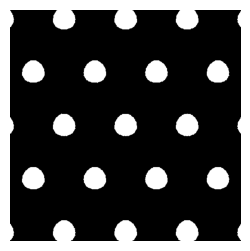

In [11]:
#visulizae one example
index = detected_names.index(detected_names[0])
img_array = detected_images[index]
print('max', np.max(img_array))

plt.figure(figsize=(3,3))
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()

In [12]:
# -----------------------------
# Hexagon shapes
# -----------------------------
my_shape = "hexagon"

detector = ShapeDetector(images=images, names=names, edge_margin=10, min_area=1000)
detected_names, detected_images = detector.detect_shapes(desired_shape=my_shape, epsilon=0.02, angle_tolerance=5, edge_tol=0.1)
print("Detected images with potential "+my_shape+" shapes:", len(detected_names))


Detected images with potential hexagon shapes: 139


max 1.0


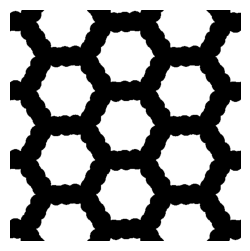

In [13]:
#visulizae one example
index = detected_names.index(detected_names[0])
img_array = detected_images[index]
print('max', np.max(img_array))

plt.figure(figsize=(3,3))
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()

In [14]:
# -----------------------------
# Star shapes
# -----------------------------
my_shape = "star"
detector = ShapeDetector(images=images, names=names, edge_margin=10, min_area=1000)
detected_names, detected_images = detector.detect_shapes(desired_shape=my_shape, epsilon=0.03,)# angle_tolerance=5, edge_tol=1)
print("Detected images with potential "+my_shape+" shapes:", len(detected_names))


Detected images with potential star shapes: 28


max 1.0


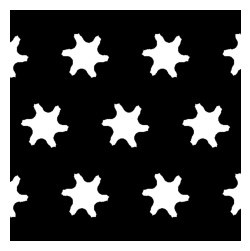

In [15]:
#visulizae one example
index = detected_names.index(detected_names[0])
img_array = detected_images[index]
print('max', np.max(img_array))

plt.figure(figsize=(3,3))
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()